In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [4]:
df=pd.read_csv('Amazon Sale Report.csv')

In [ ]:
df.shape

(28381, 21)

In [ ]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7147 entries, 0 to 7146
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               7147 non-null   int64  
 1   Order ID            7147 non-null   object 
 2   Date                7147 non-null   object 
 3   Status              7147 non-null   object 
 4   Fulfilment          7147 non-null   object 
 5   Sales Channel       7147 non-null   object 
 6   ship-service-level  7147 non-null   object 
 7   Category            7146 non-null   object 
 8   Size                7146 non-null   object 
 9   Courier Status      7146 non-null   object 
 10  Qty                 7146 non-null   float64
 11  currency            6691 non-null   object 
 12  Amount              6691 non-null   float64
 13  ship-city           7142 non-null   object 
 14  ship-state          7142 non-null   object 
 15  ship-postal-code    7142 non-null   float64
 16  ship-c

In [ ]:
#drop unrelated/blank columns
df.drop(['New','PendingS'], axis=1, inplace=True)

In [ ]:
pd.isnull(df)
# checking null value

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7142,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True
7143,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7144,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7145,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
pd.isnull(df).sum()
# sum will give total values of null values

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,1
Size,1
Courier Status,1


In [ ]:
#drop null values
df.dropna(inplace=True)

In [ ]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by'],
      dtype='object')

In [ ]:
# ship-postal-code is in float data type.
# change data type
df['ship-postal-code']=df['ship-postal-code'].astype('int')

In [ ]:
#checking whether the  data type change or not
df['ship-postal-code'].dtype

dtype('int64')

In [ ]:
#rename Columns
df.rename(columns={'Qty':'Quantity'})

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Quantity,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0.0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,False,Easy Ship
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1.0,INR,406.00,BENGALURU,KARNATAKA,560085,IN,False,Easy Ship
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0.0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False,Easy Ship
7,7,406-7807733-3785945,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,S,Shipped,1.0,INR,399.00,HYDERABAD,TELANGANA,500032,IN,False,Easy Ship
12,12,405-5513694-8146768,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,XS,Shipped,1.0,INR,399.00,Amravati.,MAHARASHTRA,444606,IN,False,Easy Ship
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7140,7139,171-8054421-0928369,2022-04-26,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,XXL,Shipped,1.0,INR,635.00,SUNDARGARH,ODISHA,770001,IN,False,Easy Ship
7141,7140,404-0286189-3305943,2022-04-26,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,XS,Shipped,1.0,INR,684.00,GREATER NOIDA,UTTAR PRADESH,201306,IN,False,Easy Ship
7143,7142,171-1271431-5842732,2022-04-26,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Blazzer,L,Shipped,1.0,INR,690.00,HYDERABAD,TELANGANA,500089,IN,False,Easy Ship
7144,7143,404-0550823-8990708,2022-04-26,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,L,Shipped,1.0,INR,1204.00,PUNE,MAHARASHTRA,411038,IN,False,Easy Ship


In [ ]:
df.describe()

,index,Date,Qty,Amount,ship-postal-code
count,2361.000000,2361,2361.000000,2361.000000,2361.000000
mean,4142.532825,2022-04-27 15:55:07.242693888,0.865311,609.707272,463841.349428
min,0.000000,2022-04-26 00:00:00,0.000000,0.000000,110002.000000
25%,2775.000000,2022-04-27 00:00:00,1.000000,434.000000,380054.000000
50%,4378.000000,2022-04-27 00:00:00,1.000000,568.000000,500012.000000
75%,5744.000000,2022-04-29 00:00:00,1.000000,737.000000,600044.000000
max,7144.000000,2022-04-30 00:00:00,3.000000,2175.000000,989898.000000
std,1929.456755,NaN,0.351250,280.965426,192944.054015


In [ ]:
df.describe(include='object')

,Order ID,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,currency,ship-city,ship-state,ship-country,B2B,fulfilled-by
count,2361,2361,2361,2361,2361,2361,2361,2361,2361,2361,2361,2361,2361,2361
unique,2134,5,1,1,1,8,10,2,1,712,38,1,2,1
top,402-1111229-8054733,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,M,Shipped,INR,BENGALURU,MAHARASHTRA,IN,False,Easy Ship
freq,8,1890,2361,2361,2361,972,452,2037,2361,189,404,2361,2344,2361


In [ ]:
#use describe() for specific columns
df[['Qty','Amount']].describe()

,Qty,Amount
count,2361.000000,2361.000000
mean,0.865311,609.707272
std,0.351250,280.965426
min,0.000000,0.000000
25%,1.000000,434.000000
50%,1.000000,568.000000
75%,1.000000,737.000000
max,3.000000,2175.000000


In [ ]:
# Exploratory Data Analysis


In [ ]:
# size

In [21]:
df.groupby(['ship-city'], as_index=False)['Qty'].value_counts().sort_values(by='Qty',ascending=False)


,ship-city,Qty,count
9375,Surat,15,1
9374,Surat,13,1
9373,Surat,9,1
3276,GUNTUR,8,1
3938,JALANDHAR,5,1
...,...,...,...
8651,SARCARSAMAKULAM,0,1
10,53miles,0,1
11155,warangal,0,2
26,ADALAJ,0,3


# Conclusion :  Surat city has maximum orders

In [ ]:
df.groupby(['Size'], as_index=False)['Qty'].sum().sort_values(by='Qty',ascending=False)

,Size,Qty
5,M,392.0
7,XL,351.0
4,L,340.0
9,XXL,270.0
0,3XL,253.0
6,S,252.0
8,XS,148.0
3,Free,34.0
2,6XL,3.0
1,5XL,0.0


[Text(0, 0, '4550'),
 Text(0, 0, '4214'),
 Text(0, 0, '4180'),
 Text(0, 0, '3471'),
 Text(0, 0, '3420'),
 Text(0, 0, '2868'),
 Text(0, 0, '2226'),
 Text(0, 0, '476'),
 Text(0, 0, '17'),
 Text(0, 0, '16'),
 Text(0, 0, '6')]

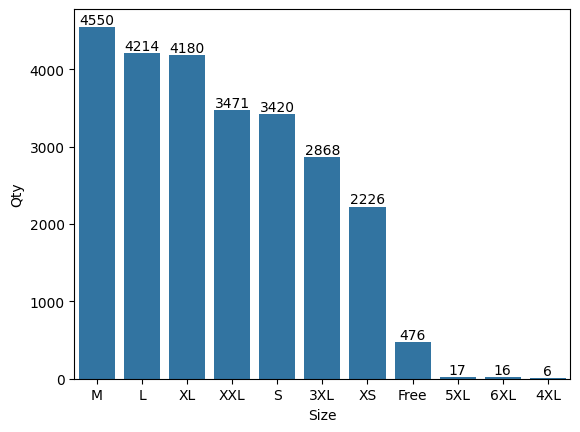

In [ ]:
S_Qty=df.groupby(['Size'], as_index=False)['Qty'].sum().sort_values(by='Qty',ascending=False)

ax=sns.barplot(x='Size',y='Qty', data=S_Qty)

ax.bar_label(ax.containers[0])

## Conclusion : From above Graph you can see that most of the Qty buys M-Size in the sales

In [ ]:
# Courier Status

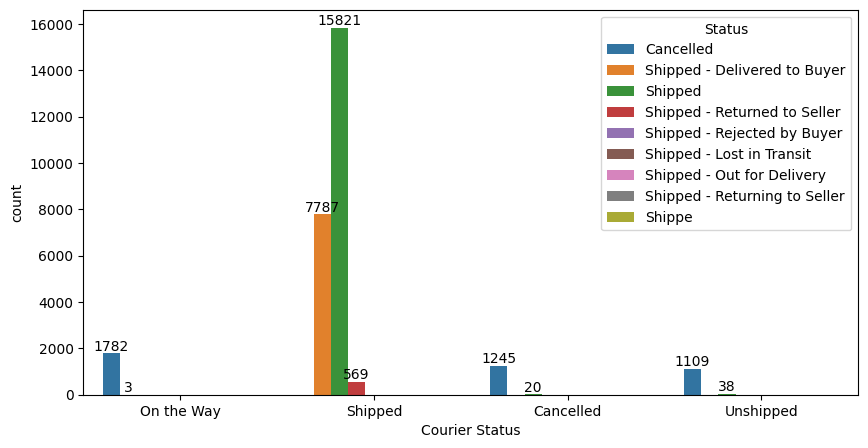

In [ ]:
plt.figure(figsize=(10,5))

ax=sns.countplot(data=df, x='Courier Status',hue= 'Status')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
ax.bar_label(ax.containers[3])
plt.show()

# Conclusion :  From above Graph the majority of the orders are shipped through the courier.

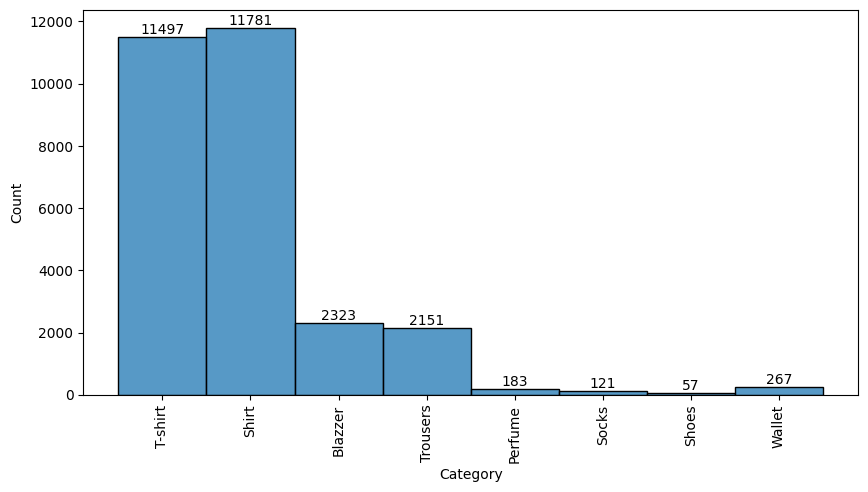

In [ ]:
column_data = df['Category']

plt.figure(figsize=(10, 5))

ax=sns.histplot(column_data, bins=30,)

plt.xticks(rotation=90)

ax.bar_label(ax.containers[0])

plt.show()

# Conclusion :  From above Graph you can see that most of the  buyers are shirt and T-shirt

In [ ]:
df['B2B']

,B2B
0,False
1,False
2,True
3,False
4,False
...,...
28376,False
28377,False
28378,False
28379,False


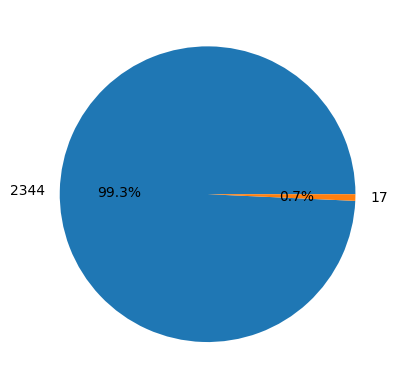

In [ ]:
# Checking B2B Data  by using pie chart
B2B_Check = df['B2B'].value_counts()

#  Plot the pie chart
plt.pie(B2B_Check, labels=B2B_Check, autopct='%1.1f%%')

plt.show()

# Conclusion : From above chart  we can see that maximum i.e. 99.3% of buyers are retailers and 0.7% are  B2B buyers

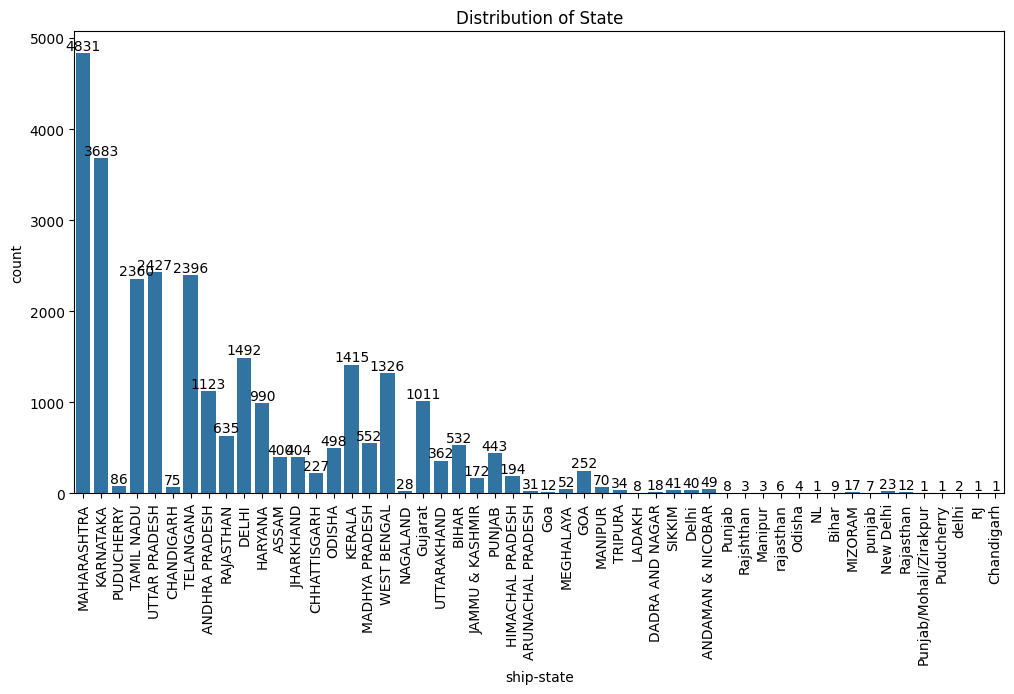

In [ ]:
# Plot count of cities by state
plt.figure(figsize=(12, 6))

ax=sns.countplot(data=df, x='ship-state')

ax.bar_label(ax.containers[0])

plt.xlabel('ship-state')

plt.ylabel('count')

plt.title('Distribution of State')

plt.xticks(rotation=90)

plt.show()


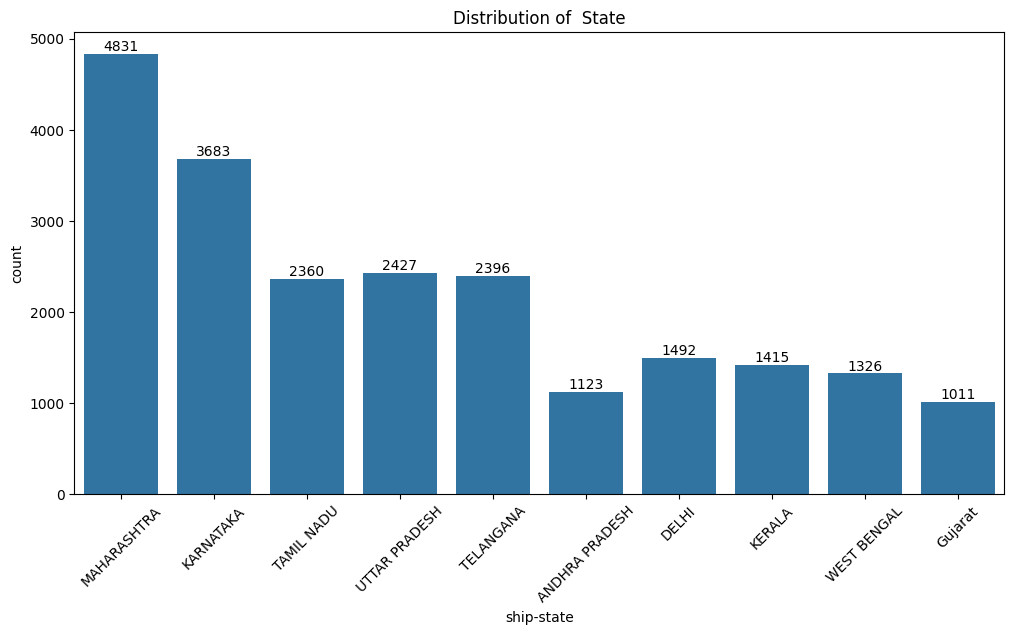

In [ ]:
# top_10_States
top_10_state = df['ship-state'].value_counts().head(10)
# Plot count of cities by state

plt.figure(figsize=(12, 6))

ax=sns.countplot(data=df[df['ship-state'].isin(top_10_state.index)], x='ship-state')

ax.bar_label(ax.containers[0])

plt.xlabel('ship-state')

plt.ylabel('count')

plt.title('Distribution of  State')

plt.xticks(rotation=45)

plt.show()

# Conclusion : From above Graph you can see that most of the  buyers are Maharashtra state